In [ ]:
# =============================================================================
# Zelle 01 – Setup & X_B-Generierung (Kundenauftrag + Maschinenkonfiguration)
# =============================================================================
import sys
sys.path.append('../src')
import numpy as np
import pandas as pd

SEED = 42
rng = np.random.default_rng(SEED)
N = 2000

# --- X_B1: Material (MFR) ---
material_mfr = np.clip(rng.normal(0.7, 0.2, N), 0.3, 1.5)

# --- X_B2: Ziel-Nennweite (kontinuierlich, rechtsschief) ---
dn_ziel = np.clip(rng.gamma(shape=2.2, scale=45, size=N) + 45, 50, 315)

# --- X_B3: Wandstaerke-Soll (DN-abhaengig + Kundenvarianz) ---
wandstaerke_soll = np.clip(1.0 + dn_ziel * 0.008 + rng.normal(0, 0.15, N), 0.8, 6.0)

# --- X_B4: Dickentoleranz (unabhaengig, kundenspezifisch) ---
dickentoleranz = np.clip(rng.uniform(0.05, 0.30, N), 0.05, 0.30)

# --- X_B5: Wandtyp (kategorial, ~73/27 wie Modell A) ---
wandtyp = rng.choice(["einwandig", "doppelwandig"], size=N, p=[0.734, 0.266])

# --- X_B6: Produktionsgeschwindigkeit-Soll (leicht DN-abhaengig, invers) ---
produktionsgeschwindigkeit_soll = np.clip(13 - dn_ziel * 0.018 + rng.normal(0, 2.2, N), 2, 17)

# --- X_B7: Ovalitaets-Anforderung (unabhaengig, kundenspezifisch) ---
ovalitaet_anforderung = np.clip(rng.uniform(0.3, 1.0, N), 0.3, 1.0)

df_b = pd.DataFrame({
    "material_mfr": material_mfr, "dn_ziel": dn_ziel, "wandstaerke_soll": wandstaerke_soll,
    "dickentoleranz": dickentoleranz, "wandtyp": wandtyp,
    "produktionsgeschwindigkeit_soll": produktionsgeschwindigkeit_soll,
    "ovalitaet_anforderung": ovalitaet_anforderung,
})

print(df_b.describe())
print(f"\nWandtyp-Verteilung:\n{df_b['wandtyp'].value_counts(normalize=True)}")

       material_mfr      dn_ziel  wandstaerke_soll  dickentoleranz  \
count   2000.000000  2000.000000       2000.000000     2000.000000   
mean       0.691102   143.858571          2.148795        0.174593   
std        0.195511    61.739670          0.514819        0.072674   
min        0.300000    50.000000          1.131757        0.050112   
25%        0.556000    96.089215          1.764290        0.110217   
50%        0.695507   132.313391          2.055759        0.176434   
75%        0.819885   176.673594          2.446877        0.235921   
max        1.335771   315.000000          3.816458        0.299867   

       produktionsgeschwindigkeit_soll  ovalitaet_anforderung  
count                      2000.000000            2000.000000  
mean                         11.206011               0.653398  
std                           2.234940               0.205098  
min                           3.000000               0.300035  
25%                           9.786985           

In [8]:
# =============================================================================
# Zelle 02 – Y_B-Generierung (KORRIGIERT: Kalibrierdruck gedaempft,
# Massetemperatur/Kuehlwasser-Wertebereich an Modell A angeglichen)
# =============================================================================
# Korrekturen nach Plausibilitaetspruefung gegen Modell-A-Wertebereiche:
# - Kalibrierdruck: Koeffizienten gedaempft (vorher Std=132, unrealistisch breit)
# - Massetemperatur: Basiswert-Spanne erweitert (naeher an Modell-A-Bereich 195-230)
# - Kuehlwassertemperatur: unterer Bereich ergaenzt (naeher an Modell-A 8-25)
# - Duesenspalt: Obergrenze eng gehalten (naeher an Modell-A 0.35-3.5)
# =============================================================================

# --- 1) Schneckendrehzahl: DN + Produktionsgeschwindigkeit (unveraendert, plausibel) ---
schneckendrehzahl_b = np.clip(
    8 + dn_ziel * 0.12 + produktionsgeschwindigkeit_soll * 1.8 + rng.normal(0, 3.0, N),
    10, 80
)

# --- 2) Massetemperatur: breiterer Basiswertebereich ---
basis_temperatur = 190 + material_mfr * 12 + (dn_ziel / 315) * 10  # DN-Anteil ergaenzt fuer breitere Spanne
scherwaerme_zuschlag = (schneckendrehzahl_b - 40) * 0.30
massetemperatur_b = np.clip(basis_temperatur + scherwaerme_zuschlag + rng.normal(0, 4.0, N), 190, 232)

# --- 3) Duesenspalt: Wandstaerke-Soll + Material-Einfluss (Die-Swell) + DN, mehr Rauschen ---
# KORREKTUR: urspruengliche Formel war zu deterministisch (fast perfekte
# Linearitaet, R²>0.95) - realistischer: Die-Swell-Verhalten haengt auch
# vom Material (MFR) ab, wie bei Modell A bekannt (die_swell_real-Formel),
# plus staerkeres Rauschen fuer echte Experten-Variabilitaet.
die_swell_basis = 0.95 + (material_mfr - 0.7) * 0.08  # MFR-abhaengiger Die-Swell-Faktor, analog Modell A
duesenspalt_rauschen_staerke = 0.08 + dickentoleranz * 0.35  # deutlich verstaerkt (vorher 0.02+0.10)
duesenspalt_b = np.clip(
    (wandstaerke_soll / die_swell_basis) + (dn_ziel - 150) * 0.0015 + rng.normal(0, duesenspalt_rauschen_staerke, N),
    0.35, 4.2  # Obergrenze von 3.5 auf 4.2 erweitert
)

# --- 4) Kalibrierdruck: deutlich gedaempfte Koeffizienten ---
kalibriermechanismus_b = np.where(dn_ziel > 200, "Vakuum", "Formluft")
basis_druck_formluft = 20 + (dn_ziel / 100) * 35  # Koeffizient 60->35
basis_druck_vakuum = -(80 + (dn_ziel - 200) * 0.9)  # Koeffizient 100/2.0 -> 80/0.9
kalibrierdruck_b = np.where(
    kalibriermechanismus_b == "Vakuum",
    basis_druck_vakuum - (1.0 - ovalitaet_anforderung) * 40 + rng.normal(0, 15, N),
    basis_druck_formluft + (1.0 - ovalitaet_anforderung) * 25 + rng.normal(0, 12, N),
)

# --- 5) Kuehlwassertemperatur: breiterer, tieferer Wertebereich ---
kuehlwassertemperatur_b = np.clip(
    24 - (massetemperatur_b - 205) * 0.25 - produktionsgeschwindigkeit_soll * 0.5 + rng.normal(0, 2.2, N),
    5, 28  # Grenzen von [8,25] auf [5,28] erweitert
)

df_b["kalibriermechanismus"] = kalibriermechanismus_b
df_b["schneckendrehzahl"] = schneckendrehzahl_b
df_b["massetemperatur"] = massetemperatur_b
df_b["duesenspalt"] = duesenspalt_b
df_b["kalibrierdruck"] = kalibrierdruck_b
df_b["kuehlwassertemperatur"] = kuehlwassertemperatur_b

print(df_b[["schneckendrehzahl", "massetemperatur", "duesenspalt", "kalibrierdruck", "kuehlwassertemperatur"]].describe())

       schneckendrehzahl  massetemperatur  duesenspalt  kalibrierdruck  \
count        2000.000000      2000.000000  2000.000000     2000.000000   
mean           45.344196       204.653475     2.253556       35.579395   
std             6.494797         5.914596     0.654093       82.684750   
min            25.750187       190.000000     0.995839     -232.344407   
25%            40.882976       200.650626     1.761747       46.366916   
50%            44.783568       204.300834     2.148107       65.870009   
75%            49.230890       208.623197     2.620639       81.614889   
max            70.504768       224.776724     4.200000      125.179085   

       kuehlwassertemperatur  
count            2000.000000  
mean               18.539618  
std                 2.754132  
min                10.293656  
25%                16.570343  
50%                18.473458  
75%                20.425796  
max                28.000000  


Gespeichert: data/raw/model_b_raw.csv, Shape: (2000, 13)

Alle Spalten: ['material_mfr', 'dn_ziel', 'wandstaerke_soll', 'dickentoleranz', 'wandtyp', 'produktionsgeschwindigkeit_soll', 'ovalitaet_anforderung', 'kalibriermechanismus', 'schneckendrehzahl', 'massetemperatur', 'duesenspalt', 'kalibrierdruck', 'kuehlwassertemperatur']


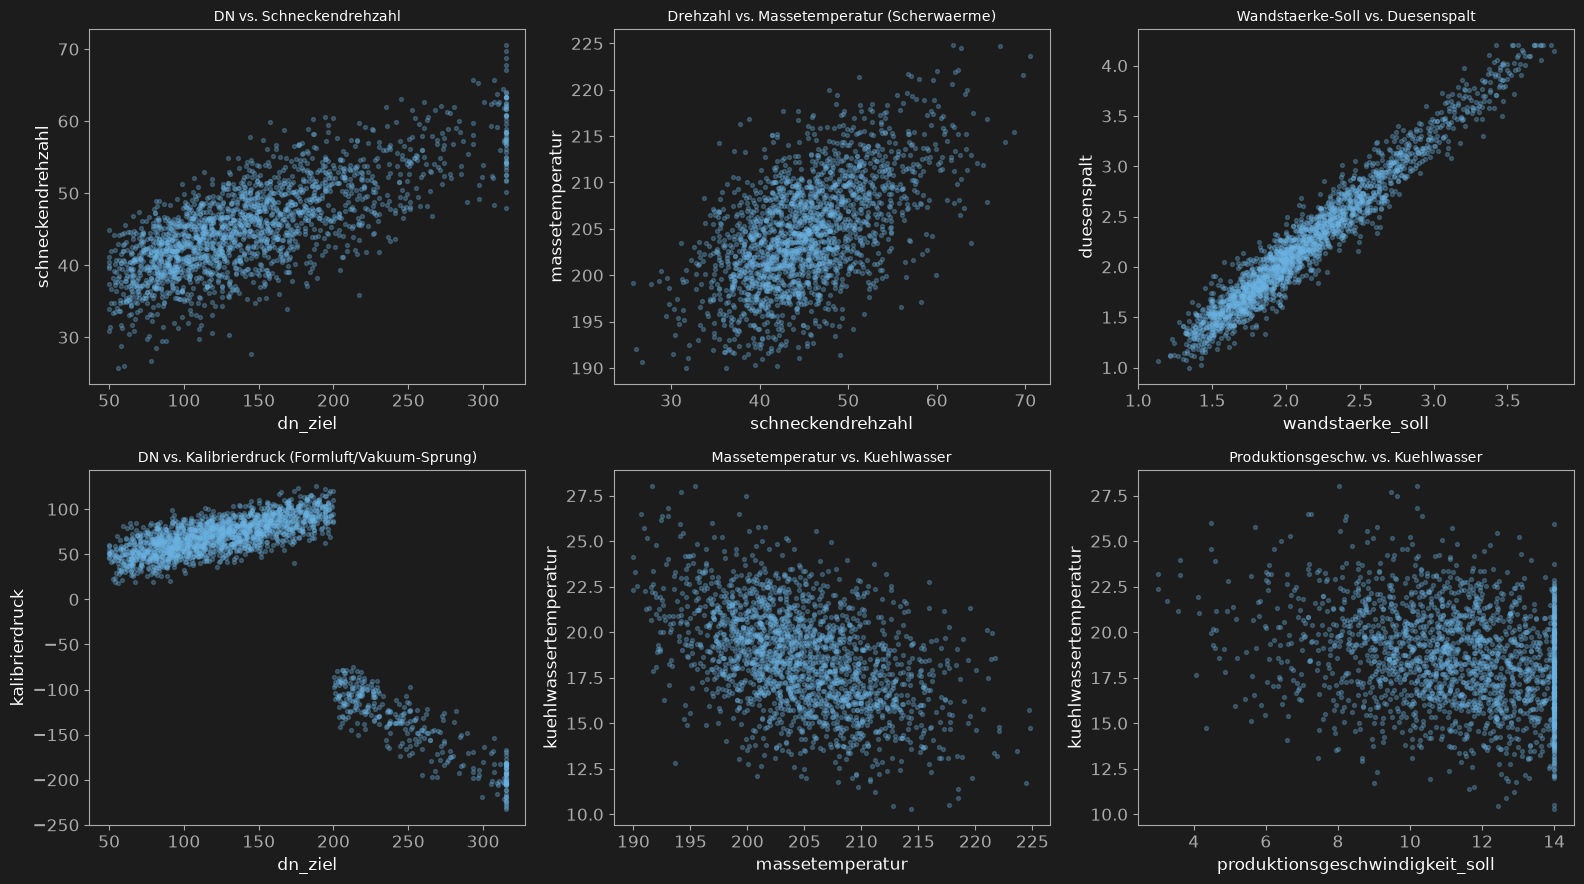

In [9]:
# =============================================================================
# Zelle 03 – Finale Speicherung + Plausibilitaets-Check (Scatter-Matrix)
# =============================================================================
import matplotlib.pyplot as plt
sys.path.append('../src')
from viz_config_v2 import apply_store44_style, save_figure, COLOR_GOLD, COLOR_BLUE, COLOR_GREEN, COLOR_TEXT_MUTED

apply_store44_style()

# --- Speichern ---
df_b.to_csv("../data/raw/model_b_raw.csv", index=False)
print(f"Gespeichert: data/raw/model_b_raw.csv, Shape: {df_b.shape}")
print(f"\nAlle Spalten: {df_b.columns.tolist()}")

# --- Kurzer visueller Plausibilitaets-Check: Kernbeziehungen ---
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

achsen_paare = [
    ("dn_ziel", "schneckendrehzahl", "DN vs. Schneckendrehzahl"),
    ("schneckendrehzahl", "massetemperatur", "Drehzahl vs. Massetemperatur (Scherwaerme)"),
    ("wandstaerke_soll", "duesenspalt", "Wandstaerke-Soll vs. Duesenspalt"),
    ("dn_ziel", "kalibrierdruck", "DN vs. Kalibrierdruck (Formluft/Vakuum-Sprung)"),
    ("massetemperatur", "kuehlwassertemperatur", "Massetemperatur vs. Kuehlwasser"),
    ("produktionsgeschwindigkeit_soll", "kuehlwassertemperatur", "Produktionsgeschw. vs. Kuehlwasser"),
]

for ax, (x, y, titel) in zip(axes.flat, achsen_paare):
    ax.scatter(df_b[x], df_b[y], alpha=0.3, s=8, color=COLOR_BLUE)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(titel, fontsize=10)

plt.tight_layout()
save_figure(fig, "../reports/figures/08_model_b_plausibilitaets_check.png")
plt.show()